In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# загрузка датасета
import warnings
warnings.filterwarnings('ignore', message=".*unauthenticated requests.*")
dataset = load_dataset("d0rj/geo-reviews-dataset-2023", split="train")

# преобразуем в pandas DataFrame для удобства
df = pd.DataFrame(dataset)

print(f"Загружено {len(df):,} отзывов")
print(f"Формат данных: {df.shape}")

Загружено 500,000 отзывов
Формат данных: (500000, 5)


In [6]:
# первичный анализ структуры данных
# посмотрим первые 5 строк
df.head()

# информация о колонках и типах данных
df.info()

# базовые статистики
df.describe(include='all')

# проверка на пропуски
print("Пропуски в каждом столбце:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   address  500000 non-null  object
 1   name_ru  499030 non-null  object
 2   rating   500000 non-null  int64 
 3   rubrics  500000 non-null  object
 4   text     500000 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.1+ MB
Пропуски в каждом столбце:
address      0
name_ru    970
rating       0
rubrics      0
text         0
dtype: int64


In [7]:
# подсчёт количества отзывов по каждой оценке
rating_counts = df['rating'].value_counts().sort_index()

print("Распределение оценок:")
for rating, count in rating_counts.items():
    pct = count / len(df) * 100
    print(f"   Оценка {rating}: {count:,} отзывов ({pct:.1f}%)")

Распределение оценок:
   Оценка 0: 200 отзывов (0.0%)
   Оценка 1: 34,351 отзывов (6.9%)
   Оценка 2: 12,088 отзывов (2.4%)
   Оценка 3: 21,686 отзывов (4.3%)
   Оценка 4: 41,160 отзывов (8.2%)
   Оценка 5: 390,515 отзывов (78.1%)


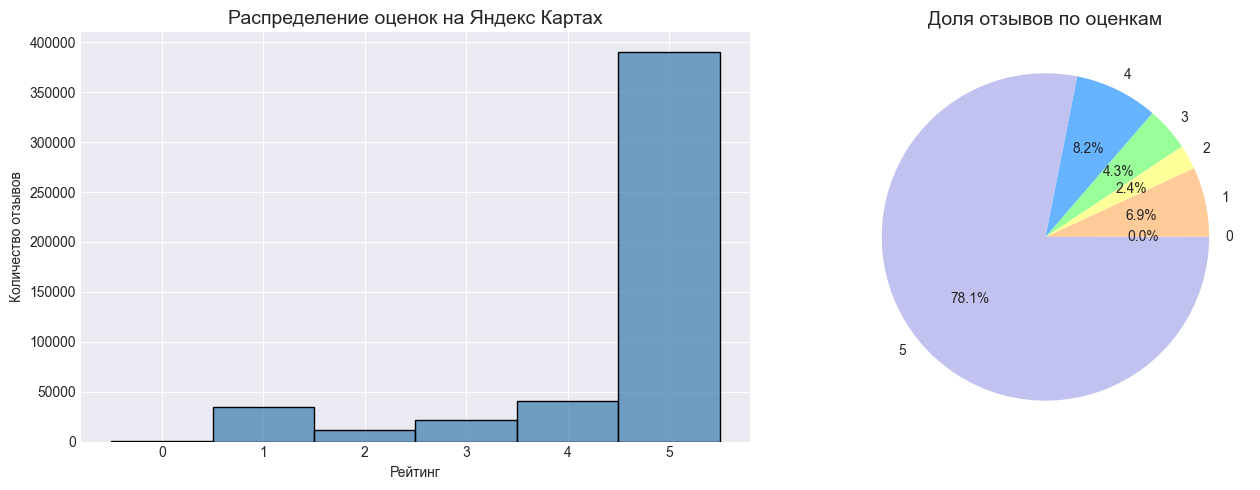

In [8]:
# визуализация распределения оценок
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# гистограмма
sns.histplot(data=df, x='rating', bins=6, discrete=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение оценок на Яндекс Картах', fontsize=14)
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Количество отзывов')

# круговая диаграмма для наглядности
rating_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], 
                   colors=['#ff9999','#ffcc99','#ffff99','#99ff99','#66b3ff','#c2c2f0'])
axes[1].set_title('Доля отзывов по оценкам', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# создаём колонку тональности (sentiment)
def get_sentiment(rating):
    if rating in [0, 1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:  # rating in [4, 5]
        return 'positive'

df['sentiment'] = df['rating'].apply(get_sentiment)

# проверяем
print("Тональность отзывов:")
print(df['sentiment'].value_counts())
print("\nВ процентах:")
print(df['sentiment'].value_counts(normalize=True) * 100)

Тональность отзывов:
sentiment
positive    431675
negative     46639
neutral      21686
Name: count, dtype: int64

В процентах:
sentiment
positive    86.3350
negative     9.3278
neutral      4.3372
Name: proportion, dtype: float64


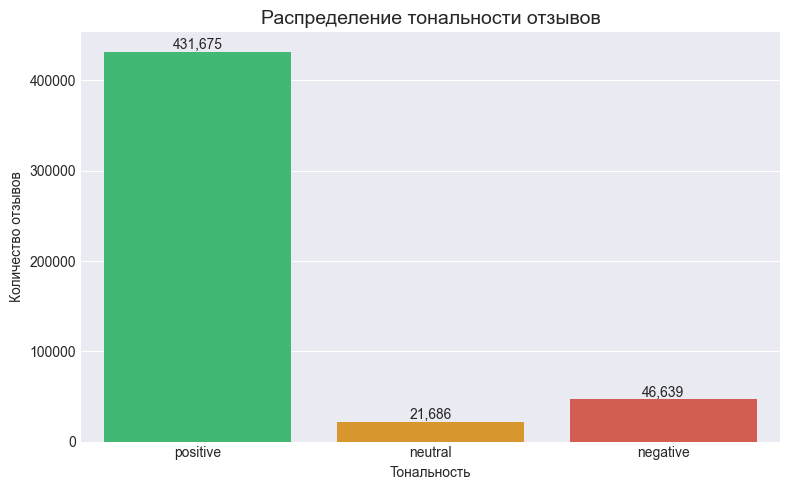

In [12]:
# визуализация тональности
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
sns.countplot(data=df, x='sentiment', order=['positive', 'neutral', 'negative'], 
              palette=colors, ax=ax)
ax.set_title('Распределение тональности отзывов', fontsize=14)
ax.set_xlabel('Тональность')
ax.set_ylabel('Количество отзывов')

# Добавляем подписи на столбцы
for i, p in enumerate(ax.patches):
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# анализ длины текста в зависимости от оценки
# добавляем колонку с длиной текста (в символах и словах)
df['text_length_chars'] = df['text'].str.len()
df['text_length_words'] = df['text'].str.split().str.len()

# статистика по оценкам
length_stats = df.groupby('rating').agg({
    'text_length_chars': ['mean', 'median', 'std'],
    'text_length_words': ['mean', 'median', 'std']
}).round(1)

print("Статистика длины текста по оценкам:")
print(length_stats)

Статистика длины текста по оценкам:
       text_length_chars               text_length_words             
                    mean median    std              mean median   std
rating                                                               
0                  254.8  206.5  192.3              36.9   28.5  29.8
1                  537.6  404.0  500.0              82.7   62.0  77.8
2                  512.5  383.0  465.4              78.6   58.0  72.7
3                  428.8  303.0  418.4              65.0   45.0  64.3
4                  337.6  238.0  318.8              49.8   35.0  48.4
5                  265.6  201.0  227.7              37.4   28.0  33.6


In [ ]:
#пока что видим:

#сильный дисбаланс: 78% оценок - пятёрки, негатива всего 9%

#негатив длиннее: оценка 1 - 537 символов в среднем, оценка 5 - 265 символов (почти ровно в 2 раза короче)

#оценка 0: всего 200 отзывов (0%), в целом можно игнорировать

In [17]:
#анализ рубрик
# смотрим первые 5 значений рубрик
print("Примеры rubrics (первые 5):")
for i in range(5):
    print(f"  {i}: {repr(df['rubrics'].iloc[i])}")
    print(f"     тип: {type(df['rubrics'].iloc[i])}")
    print()

# также проверим, что внутри
sample = df['rubrics'].iloc[0]
print(f"Длина строки: {len(sample)}")
print(f"Первые 100 символов: {sample[:100]}")

Примеры rubrics (первые 5):
  0: 'Жилой комплекс'
     тип: <class 'str'>

  1: 'Магазин продуктов;Продукты глубокой заморозки;Магазин мяса, колбас'
     тип: <class 'str'>

  2: 'Фитнес-клуб'
     тип: <class 'str'>

  3: 'Пункт проката;Прокат велосипедов;Сапсёрфинг'
     тип: <class 'str'>

  4: 'Салон красоты;Визажисты, стилисты;Салон бровей и ресниц'
     тип: <class 'str'>

Длина строки: 14
Первые 100 символов: Жилой комплекс


In [ ]:
#видно, что данные в столбце rubrics хранятся в формате:

одна рубрика: 'Жилой комплекс'

несколько рубрик: 'Магазин продуктов;Продукты глубокой заморозки;Магазин мяса, колбас'

разделитель - точка с запятой ;

In [18]:
#продолжим анализ рубрик
from collections import Counter

# разделяем по точке с запятой и собираем все рубрики
all_rubrics = []
for rubrics_str in df['rubrics'].dropna():
    # разделяем по точке с запятой
    items = rubrics_str.split(';')
    all_rubrics.extend(items)

# считаем частоту
rubric_counts = pd.Series(all_rubrics).value_counts().head(20)

print("Топ-20 рубрик заведений:")
for rubric, count in rubric_counts.items():
    print(f"   {rubric}: {count:,} отзывов")

Топ-20 рубрик заведений:
   Кафе: 58,496 отзывов
   Ресторан: 56,761 отзывов
   Гостиница: 43,133 отзывов
   Магазин продуктов: 21,346 отзывов
   Супермаркет: 19,746 отзывов
   Бар, паб: 19,238 отзывов
   Салон красоты: 17,910 отзывов
   Быстрое питание: 16,859 отзывов
   Доставка еды и обедов: 14,394 отзывов
   Ногтевая студия: 11,649 отзывов
   Автосервис, автотехцентр: 10,818 отзывов
   Кофейня: 10,531 отзывов
   Пиццерия: 9,730 отзывов
   Парикмахерская: 9,481 отзывов
   Музей: 9,102 отзывов
   Банкетный зал: 9,065 отзывов
   Парк культуры и отдыха: 8,283 отзывов
   Медцентр, клиника: 8,231 отзывов
   Торговый центр: 8,136 отзывов
   Развлекательный центр: 7,367 отзывов


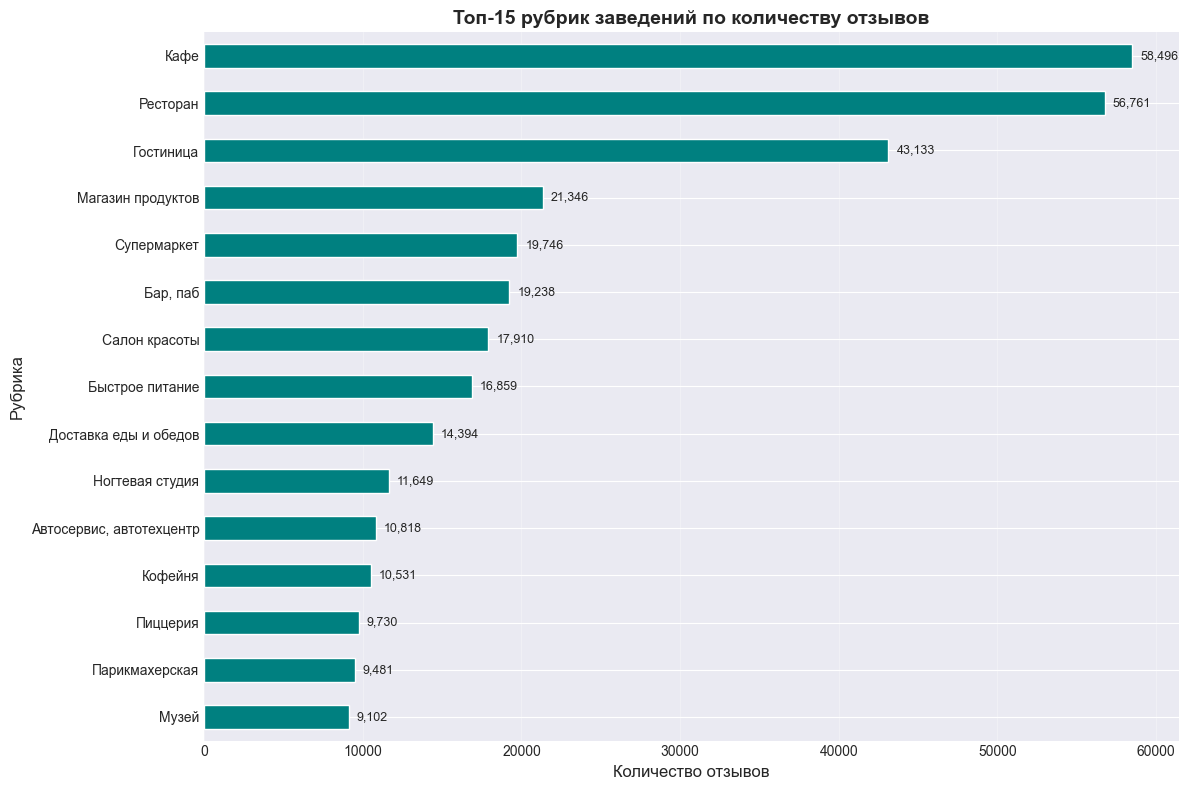

In [19]:
# визуализация топ-рубрик
fig, ax = plt.subplots(figsize=(12, 8))

# берем топ-15
top_n = 15
rubric_counts.head(top_n).plot(kind='barh', ax=ax, color='teal', edgecolor='white')

# настройки
ax.set_title(f'Топ-{top_n} рубрик заведений по количеству отзывов', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество отзывов', fontsize=12)
ax.set_ylabel('Рубрика', fontsize=12)
ax.invert_yaxis()  # самая популярная сверху

# добавляем значения на столбцы
for i, (rubric, count) in enumerate(rubric_counts.head(top_n).items()):
    ax.text(count + 500, i, f'{count:,}', va='center', fontsize=9)

# метка только по горизонтали
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('top_rubrics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
# сохраняем обработанный DataFrame для следующих шагов
df.to_csv('geo_reviews_processed.csv', index=False)
print("Данные сохранены в geo_reviews_processed.csv")
print(f"Итоговый размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

Данные сохранены в geo_reviews_processed.csv
Итоговый размер: (500000, 9)
Колонки: ['address', 'name_ru', 'rating', 'rubrics', 'text', 'sentiment', 'text_length_chars', 'text_length_words', 'rubrics_parsed']


In [21]:
# предобработка текста и лемматизация
# дополнительные библиотеки для обработки текста
import re
import string
from tqdm import tqdm  # для прогресс-бара
import nltk
from nltk.corpus import stopwords

# скачиваем стоп-слова для русского языка
nltk.download('stopwords')

# для лемматизации используем pymorphy2
import pymorphy2

print("Библиотеки загружены")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gasin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Библиотеки загружены


In [22]:
# настройка стоп-слов и лемматизатора
# русские стоп-слова из NLTK
russian_stopwords = set(stopwords.words('russian'))

# добавляем свои стоп-слова (часто встречающиеся, но не несущие смысла)
extra_stopwords = {
    'это', 'так', 'вот', 'быть', 'весь', 'который', 'тот', 'для', 'без',
    'да', 'нет', 'уже', 'ещё', 'тоже', 'очень', 'можно', 'нужно', 'стал',
    'стать', 'конечно', 'прямо', 'совсем', 'немного', 'много', 'мало',
    'весьма', 'почти', 'чуть', 'опять', 'снова', 'иногда', 'всегда',
    'никогда', 'теперь', 'потом', 'тут', 'там', 'здесь', 'куда', 'откуда',
    'зачем', 'почему', 'какой', 'такой', 'этакий', 'весьма', 'именно',
    'даже', 'неужели', 'разве', 'вдруг', 'словно', 'будто', 'как-то'
}

all_stopwords = russian_stopwords.union(extra_stopwords)
print(f"Всего стоп-слов: {len(all_stopwords)}")

Всего стоп-слов: 171


In [23]:
# инициализируем лемматизатор (pymorphy2)
morph = pymorphy2.MorphAnalyzer()

# тестовая проверка
test_words = ['хорошего', 'плохая', 'отличное', 'кофе', 'обслуживание']
print("Тест лемматизатора:")
for word in test_words:
    lemma = morph.parse(word)[0].normal_form
    print(f"  {word} → {lemma}")

Тест лемматизатора:
  хорошего → хороший
  плохая → плохой
  отличное → отличный
  кофе → кофе
  обслуживание → обслуживание


In [24]:
# создание функции очистки текста
def clean_and_lemmatize(text, verbose=False):
    """
    Полная предобработка текста:
    1. Приведение к нижнему регистру
    2. Удаление спецсимволов и цифр
    3. Удаление лишних пробелов
    4. Токенизация и лемматизация
    5. Удаление стоп-слов и коротких слов
    """
    if not isinstance(text, str):
        return ""
    
    # 1. нижний регистр
    text = text.lower()
    
    # 2. удаление пунктуации и цифр (оставляем только буквы и пробелы)
    text = re.sub(r'[^а-яё\s]', '', text)
    
    # 3. удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 4. токенизация (разбиваем на слова)
    words = text.split()
    
    # 5. лемматизация + фильтрация стоп-слов и коротких слов
    lemmatized_words = []
    for word in words:
        if len(word) <= 2:  # пропускаем слишком короткие слова
            continue
        if word in all_stopwords:  # пропускаем стоп-слова
            continue
        
        # лемматизация
        try:
            lemma = morph.parse(word)[0].normal_form
            if len(lemma) > 2 and lemma not in all_stopwords:
                lemmatized_words.append(lemma)
        except:
            # если ошибка лемматизации, пропускаем слово
            continue
    
    return ' '.join(lemmatized_words)

In [25]:
# тестирование функции
# тестируем на нескольких примерах
test_texts = [
    "Очень вкусно, быстро принесли, персонал вежливый!",
    "Ужасное место, еда невкусная, долго ждали 40 минут",
    "Нормально, но дороговато для такого качества",
    "Спасибо, всё отлично, обязательно вернёмся ещё!"
]

print("Тест очистки и лемматизации:\n")
for text in test_texts:
    cleaned = clean_and_lemmatize(text)
    print(f"Оригинал: {text}")
    print(f"Обработано: {cleaned}")
    print("-" * 50)

Тест очистки и лемматизации:

Оригинал: Очень вкусно, быстро принесли, персонал вежливый!
Обработано: вкусно быстро принести персонал вежливый
--------------------------------------------------
Оригинал: Ужасное место, еда невкусная, долго ждали 40 минут
Обработано: ужасный место еда невкусный долго ждать минута
--------------------------------------------------
Оригинал: Нормально, но дороговато для такого качества
Обработано: нормально дороговатый качество
--------------------------------------------------
Оригинал: Спасибо, всё отлично, обязательно вернёмся ещё!
Обработано: спасибо всё отлично обязательно вернуться
--------------------------------------------------


In [26]:
# функция работает, применим ко всему дата-сету
# создаём копию только нужных колонок для экономии памяти
df_clean = df[['rating', 'sentiment', 'text']].copy()

# применяем очистку
tqdm.pandas(desc="Обработка отзывов")
df_clean['clean_text'] = df_clean['text'].progress_apply(clean_and_lemmatize)

# удаляем пустые строки (если после очистки ничего не осталось)
before = len(df_clean)
df_clean = df_clean[df_clean['clean_text'].str.len() > 0]
after = len(df_clean)

print(f"\n Обработано {before:,} отзывов")
print(f"После удаления пустых осталось {after:,} отзывов ({after/before*100:.1f}%)")

Обработка отзывов: 100%|████████████████████████████████████████████████████| 500000/500000 [1:12:18<00:00, 115.24it/s]



 Обработано 500,000 отзывов
После удаления пустых осталось 499,968 отзывов (100.0%)


In [36]:
# видно ошибку лемматизации ("деньга"). исправим
# добавим пост-обработку для исправления известных проблем
def fix_lemmas(text):
    replacements = {
        'деньга': 'деньги',
        'человек': 'человек',  # оставляем как есть
        'ребёнок': 'ребёнок',
        'всё': 'все',
    }
    for bad, good in replacements.items():
        text = text.replace(f' {bad} ', f' {good} ')
    return text

# применяем к clean_text
df_clean['clean_text'] = df_clean['clean_text'].apply(fix_lemmas)

In [37]:
# проверка результатов очистки
# посмотрим несколько примеров "до" и "после"
sample_df = df_clean.sample(10)

for idx, row in sample_df.iterrows():
    print(f"Рейтинг: {row['rating']} | Тональность: {row['sentiment']}")
    print(f"До: {row['text'][:150]}...")
    print(f"После: {row['clean_text'][:150]}...")
    print("-" * 80)

Рейтинг: 5 | Тональность: positive
До: Отличная база,отличные ребята, много что по химии можно преобрести, качество огонь🙂...
После: отличный базаотличный ребята химия преобрести качество огонь...
--------------------------------------------------------------------------------
Рейтинг: 5 | Тональность: positive
До: Самое лучшее питание и производство просто суппер. Все настолько стерильно и качественно. Доверя полностью. Покупаю внукам смесь без всякой опски. Спа...
После: самый хороший питание производство просто суппер настолько стерильно качественно доверить полностью покупать внук смесь всякий опски спасибо нутриций...
--------------------------------------------------------------------------------
Рейтинг: 5 | Тональность: positive
До: Наличие Лента, Лэтуаль, Кари, фудкорт милого, славных отделов, пусть ассортимент не ультра, но есть что прикупить, где оставить ребенка и передохнуть....
После: наличие лента лэтуаля карий фудкорт милый славный отдел пусть ассортимент ультра прикупи

In [28]:
# статистика по длине очищенного текста
df_clean['clean_length_words'] = df_clean['clean_text'].str.split().str.len()

print("Статистика длины очищенного текста по тональности:")
stats = df_clean.groupby('sentiment')['clean_length_words'].agg(['mean', 'median', 'count'])
print(stats)

Статистика длины очищенного текста по тональности:
                mean  median   count
sentiment                           
negative   46.041533    35.0   46638
neutral    37.657367    27.0   21685
positive   24.665209    19.0  431645


In [ ]:
# негативные отзывы в среднем в 2 раза длиннее позитивных (46 и 24 слова) - подтверждаем ранний инсайт

In [38]:
# сохраняем для следующих шагов
df_clean.to_csv('geo_reviews_cleaned.csv', index=False)
print("Очищенные данные сохранены в geo_reviews_cleaned.csv")
print(f"Колонки: {df_clean.columns.tolist()}")

Очищенные данные сохранены в geo_reviews_cleaned.csv
Колонки: ['rating', 'sentiment', 'text', 'clean_text', 'clean_length_words']


In [39]:
# анализ ключевых слов и семантические кластеры
# разделяем очищенные тексты по тональности
positive_texts = df_clean[df_clean['sentiment'] == 'positive']['clean_text'].tolist()
negative_texts = df_clean[df_clean['sentiment'] == 'negative']['clean_text'].tolist()

print(f"Позитивных отзывов: {len(positive_texts):,}")
print(f"Негативных отзывов: {len(negative_texts):,}")

Позитивных отзывов: 431,645
Негативных отзывов: 46,638


In [40]:
# выделение топ-слов для позитивных и негативных отзывов
from collections import Counter
import pandas as pd

# функция для подсчёта частоты слов
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# получаем топ-20 слов для каждой тональности
pos_top = get_top_words(positive_texts, 20)
neg_top = get_top_words(negative_texts, 20)

print("ТОП-20 слов в ПОЗИТИВНЫХ отзывах:")
for word, count in pos_top:
    print(f"   {word}: {count:,}")

print("\n ТОП-20 слов в НЕГАТИВНЫХ отзывах:")
for word, count in neg_top:
    print(f"   {word}: {count:,}")

ТОП-20 слов в ПОЗИТИВНЫХ отзывах:
   хороший: 128,846
   место: 96,658
   отличный: 85,925
   персонал: 85,684
   спасибо: 72,779
   магазин: 66,557
   рекомендовать: 65,153
   вкусный: 64,818
   цена: 60,522
   большой: 58,254
   все: 56,904
   ребёнок: 54,099
   понравиться: 51,432
   приятный: 50,308
   вежливый: 50,044
   свой: 49,726
   выбор: 46,124
   номер: 42,409
   уютный: 42,163
   быстро: 38,148

 ТОП-20 слов в НЕГАТИВНЫХ отзывах:
   сказать: 13,151
   просто: 11,081
   день: 11,008
   человек: 9,788
   время: 9,727
   место: 9,139
   свой: 8,783
   магазин: 8,725
   заказ: 8,475
   работать: 7,845
   ребёнок: 7,766
   сделать: 7,598
   цена: 7,227
   итог: 7,226
   деньги: 7,100
   минута: 6,956
   час: 6,741
   номер: 6,679
   вообще: 6,559
   хотеть: 6,449


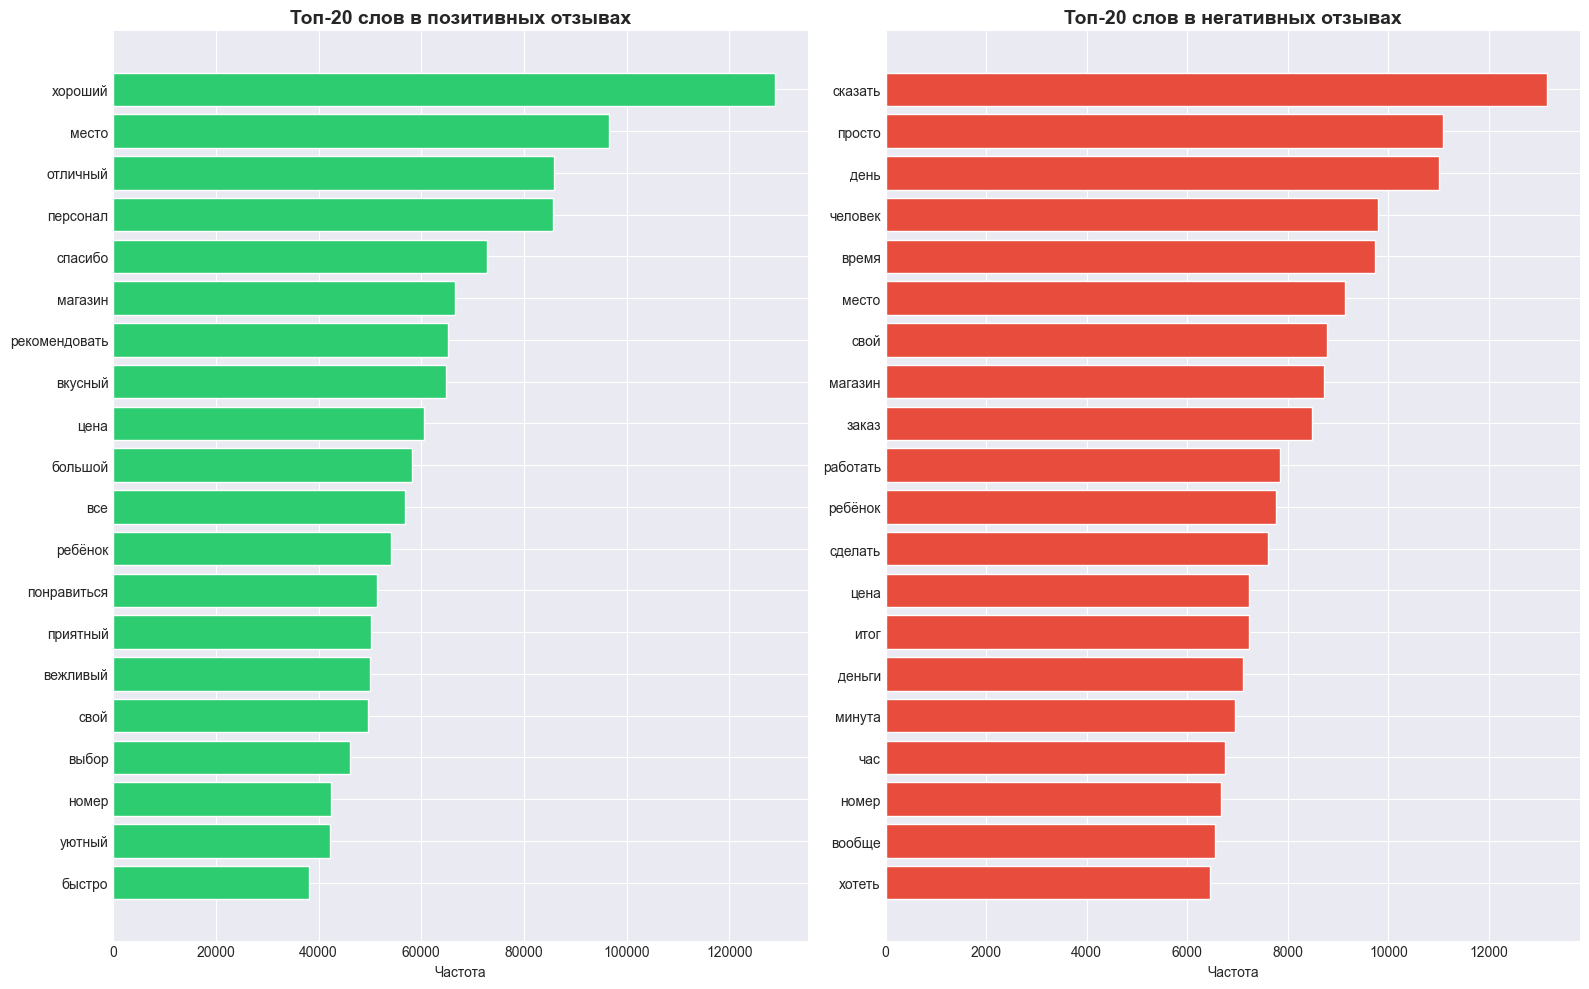

In [41]:
#визуализация топ-слов
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# позитивные слова
words_pos, counts_pos = zip(*pos_top)
axes[0].barh(words_pos, counts_pos, color='#2ecc71', edgecolor='white')
axes[0].set_title('Топ-20 слов в позитивных отзывах', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Частота')
axes[0].invert_yaxis()

# негативные слова
words_neg, counts_neg = zip(*neg_top)
axes[1].barh(words_neg, counts_neg, color='#e74c3c', edgecolor='white')
axes[1].set_title('Топ-20 слов в негативных отзывах', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Частота')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_words_by_sentiment.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [42]:
# TF-IDF для выявления уникальных маркеров
# простая частота показывает общие слова. TF-IDF покажет, какие слова специфичны именно для негатива или позитива
from sklearn.feature_extraction.text import TfidfVectorizer

# берем равное количество отзывов для баланса
min_count = min(len(positive_texts), len(negative_texts))
sample_pos = positive_texts[:min_count]
sample_neg = negative_texts[:min_count]

# создаём корпус с метками
corpus = sample_pos + sample_neg
labels = ['pos'] * min_count + ['neg'] * min_count

# TF-IDF векторизация
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 1))
X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

# средний TF-IDF для каждой тональности
import numpy as np

pos_indices = [i for i, label in enumerate(labels) if label == 'pos']
neg_indices = [i for i, label in enumerate(labels) if label == 'neg']

pos_tfidf = X[pos_indices].mean(axis=0).A1
neg_tfidf = X[neg_indices].mean(axis=0).A1

# находим слова с наибольшей разницей
diff = pos_tfidf - neg_tfidf
top_pos_unique_indices = np.argsort(diff)[-20:][::-1]
top_neg_unique_indices = np.argsort(diff)[:20]

print("ТОП-15 слов, УНИКАЛЬНЫХ для ПОЗИТИВНЫХ отзывов:")
for idx in top_pos_unique_indices[:15]:
    print(f"   {feature_names[idx]}: +{diff[idx]:.4f}")

print("\n ТОП-15 слов, УНИКАЛЬНЫХ для НЕГАТИВНЫХ отзывов:")
for idx in top_neg_unique_indices[:15]:
    print(f"   {feature_names[idx]}: {diff[idx]:.4f}")

ТОП-15 слов, УНИКАЛЬНЫХ для ПОЗИТИВНЫХ отзывов:
   отличный: +0.0372
   хороший: +0.0346
   спасибо: +0.0263
   вежливый: +0.0215
   вкусный: +0.0207
   персонал: +0.0205
   большой: +0.0201
   уютный: +0.0196
   приятный: +0.0196
   понравиться: +0.0177
   выбор: +0.0177
   прекрасный: +0.0162
   быстро: +0.0161
   вкусно: +0.0156
   чисто: +0.0154

 ТОП-15 слов, УНИКАЛЬНЫХ для НЕГАТИВНЫХ отзывов:
   сказать: -0.0219
   деньги: -0.0170
   ужасный: -0.0166
   заказ: -0.0165
   итог: -0.0163
   отвратительный: -0.0156
   вообще: -0.0140
   час: -0.0139
   ждать: -0.0137
   человек: -0.0136
   говорить: -0.0133
   минута: -0.0133
   никто: -0.0130
   просто: -0.0117
   день: -0.0109


In [44]:
# находим группы слов, которые часто встречаются вместе. это показывает, о каких темах люди пишут одновременно
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
import numpy as np

# берём 3000 негативных отзывов для анализа
neg_sample = negative_texts[:3000]

print(f"Анализируем {len(neg_sample)} негативных отзывов")

# создаём матрицу "документ-слово" (отзывы и слова)
vectorizer = CountVectorizer(
    max_features=300,  # возьмём 300 самых частых слов
    stop_words=list(all_stopwords),
    min_df=5,  # слово должно встречаться минимум в 5 отзывах
    max_df=0.5  # слово не должно быть более чем в 50% отзывов
)

# матрица: отзывы * слова
X_docs = vectorizer.fit_transform(neg_sample)
feature_words = vectorizer.get_feature_names_out()

print(f"Слов в словаре: {len(feature_words)}")

# транспонируем: теперь строки - это слова, колонки - отзывы
# каждое слово - это вектор того, в каких отзывах оно встречается
X_words = X_docs.T  # (300 слов, 3000 отзывов)

# кластеризуем слова на основе их встречаемости в отзывах
n_clusters = 6  # количество кластеров
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
word_clusters = kmeans.fit_predict(X_words)

# выводим результаты
print("\n СЕМАНТИЧЕСКИЕ КЛАСТЕРЫ СЛОВ (из негативных отзывов):\n")

# считаем "вес" каждого слова
word_freq = np.array(X_words.sum(axis=1)).flatten()

for cluster_id in range(n_clusters):
    # находим слова в этом кластере
    cluster_indices = [i for i in range(len(feature_words)) if word_clusters[i] == cluster_id]
    cluster_words = [feature_words[i] for i in cluster_indices]
    
    # сортируем слова внутри кластера по частоте
    cluster_words_with_freq = [(feature_words[i], word_freq[i]) for i in cluster_indices]
    cluster_words_with_freq.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n Кластер {cluster_id + 1} ({len(cluster_words)} слов):")
    print(f"   {', '.join([w for w, _ in cluster_words_with_freq[:12]])}")
    
    # интерпретируем на основе ключевых слов
    if 'ждать' in cluster_words or 'минута' in cluster_words or 'час' in cluster_words:
        print("   → Тема: ВРЕМЯ ОЖИДАНИЯ")
    elif 'цена' in cluster_words or 'деньги' in cluster_words or 'дорого' in cluster_words:
        print("   → Тема: ЦЕНА / ДЕНЬГИ")
    elif 'персонал' in cluster_words or 'продавец' in cluster_words or 'администратор' in cluster_words:
        print("   → Тема: ПЕРСОНАЛ / ОБСЛУЖИВАНИЕ")
    elif 'вкусный' in cluster_words or 'еда' in cluster_words or 'невкусный' in cluster_words:
        print("   → Тема: КАЧЕСТВО ЕДЫ")
    elif 'чисто' in cluster_words or 'грязно' in cluster_words or 'уютно' in cluster_words:
        print("   → Тема: ЧИСТОТА / АТМОСФЕРА")
    elif 'заказ' in cluster_words or 'принести' in cluster_words or 'привезти' in cluster_words:
        print("   → Тема: ОФОРМЛЕНИЕ ЗАКАЗА")
    else:
        print("   → Тема: УТОЧНИТЬ")

Анализируем 3000 негативных отзывов
Слов в словаре: 300

 СЕМАНТИЧЕСКИЕ КЛАСТЕРЫ СЛОВ (из негативных отзывов):


 Кластер 1 (1 слов):
   место
   → Тема: УТОЧНИТЬ

 Кластер 2 (46 слов):
   день, время, человек, магазин, свой, заказ, работать, цена, мочь, итог, сделать, деньги
   → Тема: ВРЕМЯ ОЖИДАНИЯ

 Кластер 3 (250 слов):
   хороший, заведение, персонал, ужасный, сотрудник, отношение, отвратительный, заказать, еда, плохой, рекомендовать, самый
   → Тема: ПЕРСОНАЛ / ОБСЛУЖИВАНИЕ

 Кластер 4 (1 слов):
   просто
   → Тема: УТОЧНИТЬ

 Кластер 5 (1 слов):
   сказать
   → Тема: УТОЧНИТЬ

 Кластер 6 (1 слов):
   ребёнок
   → Тема: УТОЧНИТЬ


In [ ]:
#главный инсайт: в негативных отзывах выделяются две большие темы:

#сервис и качество (самый большой кластер - 250 слов)

#время ожидания и деньги (46 слов)

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Построение визуализации (может занять 1-2 минуты)...")

# уменьшаем размерность для визуализации
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
words_2d = tsne.fit_transform(X_words.toarray())

# визуализация
fig, ax = plt.subplots(figsize=(14, 10))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for cluster_id in range(n_clusters):
    mask = word_clusters == cluster_id
    ax.scatter(words_2d[mask, 0], words_2d[mask, 1], 
               c=colors[cluster_id % len(colors)], 
               label=f'Кластер {cluster_id+1}', alpha=0.7, s=80)

# добавляем подписи для самых частых слов
top_freq_indices = np.argsort(word_freq)[-40:]
for idx in top_freq_indices:
    ax.annotate(feature_words[idx], 
                (words_2d[idx, 0], words_2d[idx, 1]),
                fontsize=9, alpha=0.8, ha='center', va='bottom')

ax.set_title('Семантические кластеры слов в негативных отзывах', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('word_clusters.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [46]:
print("=" * 70)
print("ИТОГОВЫЙ АНАЛИЗ НЕГАТИВНЫХ ОТЗЫВОВ НА ЯНДЕКС КАРТАХ")
print("=" * 70)

print("""
ОСНОВНЫЕ ВЫВОДЫ:

1. ДИСБАЛАНС ОЦЕНОК
   - 78% отзывов — оценка 5
   - Только 9% — негативные (оценки 1-2)
   → Люди чаще пишут, когда довольны

2. ДЛИНА ОТЗЫВА
   - Негативные: в среднем 46 слов
   - Позитивные: в среднем 24 слова
   → Недовольные клиенты объясняют причины подробнее

3. УНИКАЛЬНЫЕ МАРКЕРЫ НЕГАТИВА (через TF-IDF):
   - Время: «ждать», «минута», «час»
   - Деньги: «цена», «деньги», «дорого»
   - Качество: «ужасный», «отвратительный»
   - Коммуникация: «сказать», «заказ»

4. ТЕМЫ ЖАЛОБ (семантические кластеры):
    КАЧЕСТВО ОБСЛУЖИВАНИЯ (самый большой кластер)
      - персонал, отношение, сотрудник
      - ужасный, отвратительный, плохой
   
    ВРЕМЯ И ДЕНЬГИ (второй кластер)
      - ждать, минута, час, день
      - цена, деньги, заказ, итог
""")


ИТОГОВЫЙ АНАЛИЗ НЕГАТИВНЫХ ОТЗЫВОВ НА ЯНДЕКС КАРТАХ

ОСНОВНЫЕ ВЫВОДЫ:

1. ДИСБАЛАНС ОЦЕНОК
   - 78% отзывов — оценка 5
   - Только 9% — негативные (оценки 1-2)
   → Люди чаще пишут, когда довольны

2. ДЛИНА ОТЗЫВА
   - Негативные: в среднем 46 слов
   - Позитивные: в среднем 24 слова
   → Недовольные клиенты объясняют причины подробнее

3. УНИКАЛЬНЫЕ МАРКЕРЫ НЕГАТИВА (через TF-IDF):
   - Время: «ждать», «минута», «час»
   - Деньги: «цена», «деньги», «дорого»
   - Качество: «ужасный», «отвратительный»
   - Коммуникация: «сказать», «заказ»

4. ТЕМЫ ЖАЛОБ (семантические кластеры):
    КАЧЕСТВО ОБСЛУЖИВАНИЯ (самый большой кластер)
      - персонал, отношение, сотрудник
      - ужасный, отвратительный, плохой
   
    ВРЕМЯ И ДЕНЬГИ (второй кластер)
      - ждать, минута, час, день
      - цена, деньги, заказ, итог

